# Robot Mission MAS — Simulation complète
**Groupe** | **Date** | **Membres**

Simulation d'agents robots collectant des déchets radioactifs dans 3 zones.

## 0. Installation

In [ ]:
# Installer Mesa si nécessaire
# !pip install mesa matplotlib numpy

## 1. Imports

In [1]:
from mesa import Agent, Model
from mesa.space import MultiGrid
from mesa.datacollection import DataCollector
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from IPython.display import clear_output
import time

print("Imports OK")

Imports OK


## 2. Objects — agents passifs (objects.py)

In [2]:
class Radioactivity(Agent):
    """
    Agent passif placé sur chaque cellule.
    Encode la zone via son niveau de radioactivité.
    - z1 : 0.00 - 0.33  (faible)
    - z2 : 0.33 - 0.66  (moyen)
    - z3 : 0.66 - 1.00  (élevé)
    """
    def __init__(self, model, level: float):
        super().__init__(model)
        self.level = level


class Waste(Agent):
    """
    Représente un déchet sur la grille.
    waste_type : 'green', 'yellow', ou 'red'
    """
    def __init__(self, model, waste_type: str):
        super().__init__(model)
        self.waste_type = waste_type
        self.collected = False   # True quand déposé en zone de dépôt


class WasteDisposalZone(Agent):
    """
    Zone de dépôt final — cellule la plus à l'est en z3.
    Agent passif, pas de comportement.
    """
    def __init__(self, model):
        super().__init__(model)


print("Objects définis : Radioactivity, Waste, WasteDisposalZone")

Objects définis : Radioactivity, Waste, WasteDisposalZone


## 3. Agents robots (agents.py)

Chaque robot suit le cycle : **percepts → update_knowledge → deliberate → do**

In [3]:
# ─────────────────────────────────────────────
# GREEN ROBOT — zone z1 uniquement
#   - ramasse 2 déchets verts
#   - transforme en 1 jaune
#   - dépose le jaune à la frontière z1/z2
# ─────────────────────────────────────────────
class GreenAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.carrying = []          # liste de Waste portés
        self.knowledge = {
            "pos": None,
            "radioactivity": 0.0,
            "wastes_here": [],
            "carrying": [],
        }

    # ── PERCEPTS ─────────────────────────────
    def perceive(self) -> dict:
        """Lit le contenu de la cellule courante."""
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        radio = next((a for a in cellmates if isinstance(a, Radioactivity)), None)
        wastes = [a for a in cellmates
                  if isinstance(a, Waste) and not a.collected]
        return {
            "pos": self.pos,
            "radioactivity": radio.level if radio else 0.0,
            "wastes_here": wastes,
            "carrying": self.carrying[:],
        }

    def update_knowledge(self, percepts: dict):
        self.knowledge.update(percepts)

    # ── DELIBERATE ───────────────────────────
    def deliberate(self) -> dict:
        """
        Raisonnement à partir de self.knowledge uniquement.
        Retourne une action sous forme de dict.
        """
        pos = self.knowledge["pos"]
        carrying = self.knowledge["carrying"]

        # 1. Transformer 2 verts → 1 jaune
        if len(carrying) == 2 and all(w.waste_type == "green" for w in carrying):
            return {"type": "transform"}

        # 2. Déposer le jaune à la frontière z1/z2
        if len(carrying) == 1 and carrying[0].waste_type == "yellow":
            if pos[0] >= self.model.zone_width - 1:
                return {"type": "put_down"}
            return {"type": "move", "direction": (1, 0)}  # aller vers l'est

        # 3. Ramasser un déchet vert sur la cellule
        green_wastes = [w for w in self.knowledge["wastes_here"]
                        if w.waste_type == "green"]
        if green_wastes and len(carrying) < 2:
            return {"type": "pick_up", "waste": green_wastes[0]}

        # 4. Se déplacer aléatoirement dans z1
        return {"type": "move",
                "direction": self.model.random.choice([(1,0),(-1,0),(0,1),(0,-1)])}

    # ── STEP ─────────────────────────────────
    def step(self):
        percepts = self.perceive()
        self.update_knowledge(percepts)
        action = self.deliberate()
        self.model.do(self, action)


# ─────────────────────────────────────────────
# YELLOW ROBOT — zones z1 et z2
#   - ramasse 2 déchets jaunes
#   - transforme en 1 rouge
#   - dépose le rouge à la frontière z2/z3
# ─────────────────────────────────────────────
class YellowAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.carrying = []
        self.knowledge = {
            "pos": None,
            "radioactivity": 0.0,
            "wastes_here": [],
            "carrying": [],
        }

    def perceive(self) -> dict:
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        radio = next((a for a in cellmates if isinstance(a, Radioactivity)), None)
        wastes = [a for a in cellmates
                  if isinstance(a, Waste) and not a.collected]
        return {
            "pos": self.pos,
            "radioactivity": radio.level if radio else 0.0,
            "wastes_here": wastes,
            "carrying": self.carrying[:],
        }

    def update_knowledge(self, percepts: dict):
        self.knowledge.update(percepts)

    def deliberate(self) -> dict:
        pos = self.knowledge["pos"]
        carrying = self.knowledge["carrying"]
        limit = 2 * self.model.zone_width  # frontière z2/z3

        # 1. Transformer 2 jaunes → 1 rouge
        if len(carrying) == 2 and all(w.waste_type == "yellow" for w in carrying):
            return {"type": "transform"}

        # 2. Déposer le rouge à la frontière z2/z3
        if len(carrying) == 1 and carrying[0].waste_type == "red":
            if pos[0] >= limit - 1:
                return {"type": "put_down"}
            return {"type": "move", "direction": (1, 0)}

        # 3. Ramasser un déchet jaune
        yellow_wastes = [w for w in self.knowledge["wastes_here"]
                         if w.waste_type == "yellow"]
        if yellow_wastes and len(carrying) < 2:
            return {"type": "pick_up", "waste": yellow_wastes[0]}

        # 4. Se déplacer aléatoirement dans z1-z2
        return {"type": "move",
                "direction": self.model.random.choice([(1,0),(-1,0),(0,1),(0,-1)])}

    def step(self):
        percepts = self.perceive()
        self.update_knowledge(percepts)
        action = self.deliberate()
        self.model.do(self, action)


# ─────────────────────────────────────────────
# RED ROBOT — zones z1, z2 et z3
#   - ramasse 1 déchet rouge
#   - le transporte vers la zone de dépôt
# ─────────────────────────────────────────────
class RedAgent(Agent):
    def __init__(self, model):
        super().__init__(model)
        self.carrying = []
        self.knowledge = {
            "pos": None,
            "radioactivity": 0.0,
            "wastes_here": [],
            "carrying": [],
        }

    def perceive(self) -> dict:
        cellmates = self.model.grid.get_cell_list_contents([self.pos])
        radio = next((a for a in cellmates if isinstance(a, Radioactivity)), None)
        wastes = [a for a in cellmates
                  if isinstance(a, Waste) and not a.collected]
        disposal = any(isinstance(a, WasteDisposalZone) for a in cellmates)
        return {
            "pos": self.pos,
            "radioactivity": radio.level if radio else 0.0,
            "wastes_here": wastes,
            "carrying": self.carrying[:],
            "on_disposal": disposal,
        }

    def update_knowledge(self, percepts: dict):
        self.knowledge.update(percepts)

    def deliberate(self) -> dict:
        carrying = self.knowledge["carrying"]
        pos = self.knowledge["pos"]
        disposal = self.model.disposal_pos

        # 1. Déposer si on est sur la zone de dépôt
        if carrying and self.knowledge.get("on_disposal"):
            return {"type": "put_down"}

        # 2. Si on porte un rouge, naviguer vers la zone de dépôt
        if carrying:
            dx = 1 if disposal[0] > pos[0] else (-1 if disposal[0] < pos[0] else 0)
            dy = 1 if disposal[1] > pos[1] else (-1 if disposal[1] < pos[1] else 0)
            # Préférer le déplacement horizontal
            if dx != 0:
                return {"type": "move", "direction": (dx, 0)}
            return {"type": "move", "direction": (0, dy)}

        # 3. Ramasser un déchet rouge
        red_wastes = [w for w in self.knowledge["wastes_here"]
                      if w.waste_type == "red"]
        if red_wastes:
            return {"type": "pick_up", "waste": red_wastes[0]}

        # 4. Se déplacer aléatoirement
        return {"type": "move",
                "direction": self.model.random.choice([(1,0),(-1,0),(0,1),(0,-1)])}

    def step(self):
        percepts = self.perceive()
        self.update_knowledge(percepts)
        action = self.deliberate()
        self.model.do(self, action)


print("Robots définis : GreenAgent, YellowAgent, RedAgent")

Robots définis : GreenAgent, YellowAgent, RedAgent


## 4. Model + méthode do() (model.py)

In [4]:
class RobotMission(Model):
    """
    Modèle principal.
    - Crée la grille, les zones radioactives, les déchets et les robots.
    - Arbitre toutes les actions via do().
    """

    def __init__(self,
                 width: int = 18,
                 height: int = 8,
                 n_green_robots: int = 3,
                 n_yellow_robots: int = 2,
                 n_red_robots: int = 2,
                 n_green_wastes: int = 8,
                 seed: int = None):
        super().__init__(seed=seed)

        self.width = width
        self.height = height
        self.zone_width = width // 3   # largeur de chaque zone
        self.grid = MultiGrid(width, height, torus=False)
        self.collected_count = 0
        self.running = True

        # Construction du monde
        self._place_radioactivity()
        self._place_waste_disposal()
        self._place_initial_wastes(n_green_wastes)
        self._place_robots(n_green_robots, n_yellow_robots, n_red_robots)

        # Collecte de données
        self.datacollector = DataCollector(model_reporters={
            "Déchets verts": lambda m: self._count_waste("green"),
            "Déchets jaunes": lambda m: self._count_waste("yellow"),
            "Déchets rouges": lambda m: self._count_waste("red"),
            "Déposés": lambda m: m.collected_count,
        })

    # ── SETUP ────────────────────────────────
    def _place_radioactivity(self):
        """Une instance Radioactivity par cellule."""
        for x in range(self.width):
            for y in range(self.height):
                if x < self.zone_width:
                    level = self.random.uniform(0.0, 0.33)
                elif x < 2 * self.zone_width:
                    level = self.random.uniform(0.33, 0.66)
                else:
                    level = self.random.uniform(0.66, 1.0)
                self.grid.place_agent(Radioactivity(self, level), (x, y))

    def _place_waste_disposal(self):
        """Zone de dépôt : colonne la plus à l'est, hauteur aléatoire."""
        y = self.random.randint(0, self.height - 1)
        self.disposal_pos = (self.width - 1, y)
        self.grid.place_agent(WasteDisposalZone(self), self.disposal_pos)

    def _place_initial_wastes(self, n: int):
        """Déchets verts initiaux uniquement dans z1."""
        for _ in range(n):
            x = self.random.randint(0, self.zone_width - 1)
            y = self.random.randint(0, self.height - 1)
            self.grid.place_agent(Waste(self, "green"), (x, y))

    def _place_robots(self, n_green: int, n_yellow: int, n_red: int):
        """Place les robots dans leurs zones respectives."""
        for _ in range(n_green):
            x = self.random.randint(0, self.zone_width - 1)
            y = self.random.randint(0, self.height - 1)
            self.grid.place_agent(GreenAgent(self), (x, y))

        for _ in range(n_yellow):
            x = self.random.randint(self.zone_width, 2 * self.zone_width - 1)
            y = self.random.randint(0, self.height - 1)
            self.grid.place_agent(YellowAgent(self), (x, y))

        for _ in range(n_red):
            x = self.random.randint(2 * self.zone_width, self.width - 1)
            y = self.random.randint(0, self.height - 1)
            self.grid.place_agent(RedAgent(self), (x, y))

    # ── DO — arbitre des actions ──────────────
    def do(self, agent, action: dict) -> dict:
        """
        Exécute l'action demandée par l'agent après vérification.
        Retourne les percepts mis à jour.
        """
        t = action["type"]

        if t == "move":
            dx, dy = action["direction"]
            x, y = agent.pos
            nx, ny = x + dx, y + dy

            # Hors grille
            if self.grid.out_of_bounds((nx, ny)):
                return {}

            # Restriction de zone
            if isinstance(agent, GreenAgent) and nx >= self.zone_width:
                return {}
            if isinstance(agent, YellowAgent) and nx >= 2 * self.zone_width:
                return {}
            # RedAgent peut aller partout

            self.grid.move_agent(agent, (nx, ny))

        elif t == "pick_up":
            waste = action["waste"]
            # Vérification : le déchet est bien là
            cell_contents = self.grid.get_cell_list_contents([agent.pos])
            if waste in cell_contents and not waste.collected:
                self.grid.remove_agent(waste)
                agent.carrying.append(waste)

        elif t == "transform":
            # GreenAgent : 2 verts → 1 jaune
            if (isinstance(agent, GreenAgent)
                    and len(agent.carrying) == 2
                    and all(w.waste_type == "green" for w in agent.carrying)):
                agent.carrying.clear()
                agent.carrying.append(Waste(self, "yellow"))

            # YellowAgent : 2 jaunes → 1 rouge
            elif (isinstance(agent, YellowAgent)
                    and len(agent.carrying) == 2
                    and all(w.waste_type == "yellow" for w in agent.carrying)):
                agent.carrying.clear()
                agent.carrying.append(Waste(self, "red"))

        elif t == "put_down":
            for waste in agent.carrying:
                if isinstance(agent, RedAgent):
                    # Dépôt définitif
                    waste.collected = True
                    self.collected_count += 1
                else:
                    # Passage entre zones : pose sur la grille
                    self.grid.place_agent(waste, agent.pos)
            agent.carrying.clear()

        return {}

    # ── HELPERS ──────────────────────────────
    def _count_waste(self, waste_type: str) -> int:
        return sum(
            1 for a in self.agents
            if isinstance(a, Waste)
            and a.waste_type == waste_type
            and not a.collected
            and a.pos is not None   # sur la grille
        )

    def _total_waste_on_grid(self) -> int:
        return sum(
            1 for a in self.agents
            if isinstance(a, Waste) and not a.collected and a.pos is not None
        )

    # ── STEP ─────────────────────────────────
    def step(self):
        self.datacollector.collect(self)
        # Activer les robots dans un ordre aléatoire
        robots = (
            list(self.agents_by_type[GreenAgent]) +
            list(self.agents_by_type[YellowAgent]) +
            list(self.agents_by_type[RedAgent])
        )
        self.random.shuffle(robots)
        for robot in robots:
            robot.step()

        # Arrêter quand tout est collecté
        if self._total_waste_on_grid() == 0 and all(
            len(r.carrying) == 0 for r in robots
        ):
            self.running = False


print("Modèle RobotMission défini")

Modèle RobotMission défini


## 5. Visualisation — fonctions de dessin

In [5]:
# Couleurs
COLORS = {
    "z1": "#d4edda",   # vert pâle
    "z2": "#fff3cd",   # jaune pâle
    "z3": "#f8d7da",   # rouge pâle
    "green_robot": "#28a745",
    "yellow_robot": "#ffc107",
    "red_robot": "#dc3545",
    "green_waste": "#8BC34A",
    "yellow_waste": "#FFD700",
    "red_waste": "#FF5733",
    "disposal": "#6f42c1",
}

def draw_grid(model, ax):
    """Dessine la grille à un instant t."""
    ax.clear()
    W, H = model.width, model.height
    zw = model.zone_width

    # ── Fond des zones ────────────────────────
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((0, 0), zw, H,       color=COLORS["z1"], zorder=0))
    ax.add_patch(Rectangle((zw, 0), zw, H,      color=COLORS["z2"], zorder=0))
    ax.add_patch(Rectangle((2*zw, 0), W-2*zw, H, color=COLORS["z3"], zorder=0))

    # ── Grille ────────────────────────────────
    for x in range(W + 1):
        ax.axvline(x, color="gray", linewidth=0.3, alpha=0.5)
    for y in range(H + 1):
        ax.axhline(y, color="gray", linewidth=0.3, alpha=0.5)

    # ── Frontières de zones ───────────────────
    ax.axvline(zw,   color="#555", linewidth=1.5, linestyle="--", alpha=0.7)
    ax.axvline(2*zw, color="#555", linewidth=1.5, linestyle="--", alpha=0.7)

    # ── Contenu des cellules ──────────────────
    for x in range(W):
        for y in range(H):
            cell = model.grid.get_cell_list_contents([(x, y)])

            # Zone de dépôt
            if any(isinstance(a, WasteDisposalZone) for a in cell):
                ax.add_patch(Rectangle((x+0.05, y+0.05), 0.9, 0.9,
                                       color=COLORS["disposal"], alpha=0.3, zorder=1))
                ax.text(x+0.5, y+0.5, "⬛", ha="center", va="center",
                        fontsize=9, zorder=3)

            # Déchets (petits carrés)
            waste_offset = 0.0
            for a in cell:
                if isinstance(a, Waste) and not a.collected and a.pos is not None:
                    c = {"green": COLORS["green_waste"],
                         "yellow": COLORS["yellow_waste"],
                         "red": COLORS["red_waste"]}[a.waste_type]
                    ax.add_patch(Rectangle((x+0.1+waste_offset, y+0.1),
                                           0.25, 0.25, color=c, zorder=2))
                    waste_offset += 0.22

            # Robots (cercles)
            for a in cell:
                if isinstance(a, GreenAgent):
                    circle = plt.Circle((x+0.5, y+0.5), 0.35,
                                        color=COLORS["green_robot"], zorder=4)
                    ax.add_patch(circle)
                    label = f"{len(a.carrying)}G"
                    ax.text(x+0.5, y+0.5, label, ha="center", va="center",
                            fontsize=7, color="white", fontweight="bold", zorder=5)

                elif isinstance(a, YellowAgent):
                    circle = plt.Circle((x+0.5, y+0.5), 0.35,
                                        color=COLORS["yellow_robot"], zorder=4)
                    ax.add_patch(circle)
                    label = f"{len(a.carrying)}Y"
                    ax.text(x+0.5, y+0.5, label, ha="center", va="center",
                            fontsize=7, color="#333", fontweight="bold", zorder=5)

                elif isinstance(a, RedAgent):
                    circle = plt.Circle((x+0.5, y+0.5), 0.35,
                                        color=COLORS["red_robot"], zorder=4)
                    ax.add_patch(circle)
                    label = f"{len(a.carrying)}R"
                    ax.text(x+0.5, y+0.5, label, ha="center", va="center",
                            fontsize=7, color="white", fontweight="bold", zorder=5)

    # ── Labels des zones ──────────────────────
    ax.text(zw/2,     H+0.15, "z1 — faible",  ha="center", fontsize=9, color="#2d6a2d")
    ax.text(zw*1.5,   H+0.15, "z2 — moyen",   ha="center", fontsize=9, color="#7a5c00")
    ax.text(zw*2.5,   H+0.15, "z3 — élevé",   ha="center", fontsize=9, color="#8b1a1a")

    # ── Légende ───────────────────────────────
    legend_elems = [
        mpatches.Patch(color=COLORS["green_robot"],  label="Robot vert"),
        mpatches.Patch(color=COLORS["yellow_robot"], label="Robot jaune"),
        mpatches.Patch(color=COLORS["red_robot"],    label="Robot rouge"),
        mpatches.Patch(color=COLORS["green_waste"],  label="Déchet vert"),
        mpatches.Patch(color=COLORS["yellow_waste"], label="Déchet jaune"),
        mpatches.Patch(color=COLORS["red_waste"],    label="Déchet rouge"),
        mpatches.Patch(color=COLORS["disposal"],     alpha=0.5, label="Zone dépôt"),
    ]
    ax.legend(handles=legend_elems, loc="upper left",
              bbox_to_anchor=(1.01, 1), fontsize=8, framealpha=0.9)

    ax.set_xlim(0, W)
    ax.set_ylim(0, H + 0.4)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(f"Step {model.steps} — déposés : {model.collected_count}",
                 fontsize=11, pad=6)


print("Fonctions de visualisation prêtes")

Fonctions de visualisation prêtes


## 6. Lancer et observer la simulation pas à pas

In [6]:
# ── Paramètres ────────────────────────────────
N_STEPS      = 60     # nombre de ticks
DRAW_EVERY   = 1      # dessiner toutes les N étapes
PAUSE        = 0.3    # secondes entre chaque frame

# Créer le modèle
model = RobotMission(
    width=18, height=8,
    n_green_robots=3,
    n_yellow_robots=2,
    n_red_robots=2,
    n_green_wastes=8,
    seed=42
)

# ── Boucle de simulation animée ───────────────
fig, ax = plt.subplots(figsize=(13, 5))
plt.tight_layout()

for step in range(N_STEPS):
    if not model.running:
        print(f"✅ Simulation terminée au step {step} !")
        break

    model.step()

    if step % DRAW_EVERY == 0:
        clear_output(wait=True)
        draw_grid(model, ax)
        plt.tight_layout()
        plt.show()
        time.sleep(PAUSE)

print(f"Step final : {model.steps} | Déchets déposés : {model.collected_count}")

<Figure size 640x480 with 0 Axes>

Step final : 60 | Déchets déposés : 0


## 7. Graphiques — évolution des déchets dans le temps

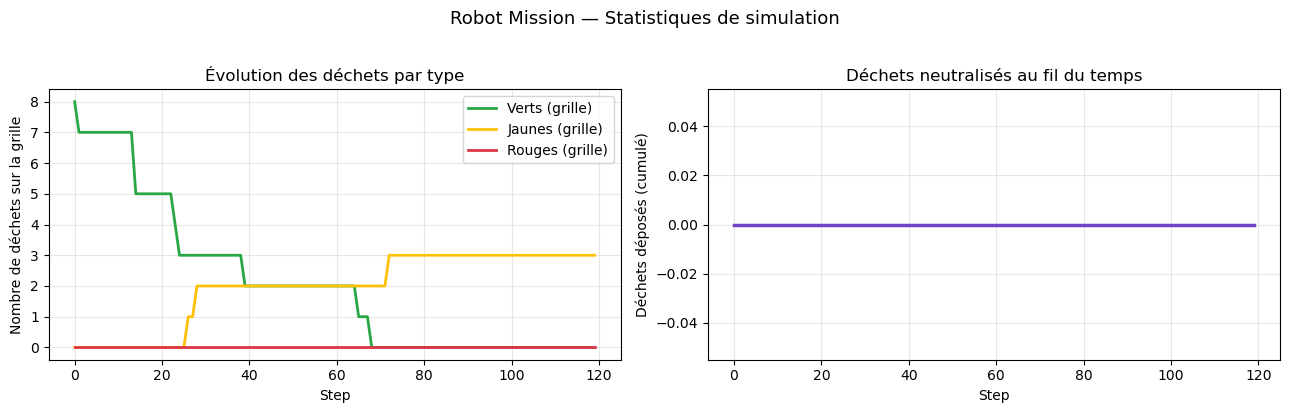

     Déchets verts  Déchets jaunes  Déchets rouges  Déposés
110              0               3               0        0
111              0               3               0        0
112              0               3               0        0
113              0               3               0        0
114              0               3               0        0
115              0               3               0        0
116              0               3               0        0
117              0               3               0        0
118              0               3               0        0
119              0               3               0        0


In [7]:
# Relancer une simulation complète pour collecter toutes les données
model2 = RobotMission(
    width=18, height=8,
    n_green_robots=3, n_yellow_robots=2, n_red_robots=2,
    n_green_wastes=8,
    seed=42
)

for _ in range(120):
    if not model2.running:
        break
    model2.step()

df = model2.datacollector.get_model_vars_dataframe()

# ── Graphique ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Courbe déchets par type
ax1 = axes[0]
ax1.plot(df.index, df["Déchets verts"],  color="#28a745", linewidth=2, label="Verts (grille)")
ax1.plot(df.index, df["Déchets jaunes"], color="#ffc107", linewidth=2, label="Jaunes (grille)")
ax1.plot(df.index, df["Déchets rouges"], color="#dc3545", linewidth=2, label="Rouges (grille)")
ax1.set_xlabel("Step")
ax1.set_ylabel("Nombre de déchets sur la grille")
ax1.set_title("Évolution des déchets par type")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Courbe déchets déposés
ax2 = axes[1]
ax2.plot(df.index, df["Déposés"], color="#6f42c1", linewidth=2.5)
ax2.fill_between(df.index, df["Déposés"], alpha=0.15, color="#6f42c1")
ax2.set_xlabel("Step")
ax2.set_ylabel("Déchets déposés (cumulé)")
ax2.set_title("Déchets neutralisés au fil du temps")
ax2.grid(True, alpha=0.3)

plt.suptitle("Robot Mission — Statistiques de simulation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(df.tail(10))

## 8. Snapshot final — état de la grille

C:\Users\user\AppData\Local\Temp\ipykernel_38308\895872898.py:3: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from current font.
  plt.tight_layout()
c:\Users\user\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 11035 (\N{BLACK LARGE SQUARE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


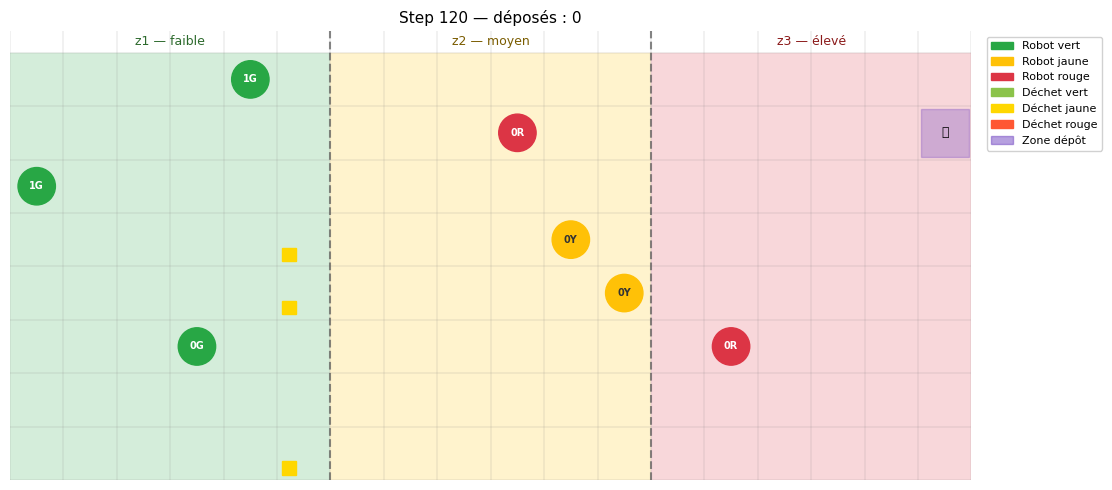

Simulation terminée en 120 steps
Déchets neutralisés : 0


In [8]:
fig, ax = plt.subplots(figsize=(13, 5))
draw_grid(model2, ax)
plt.tight_layout()
plt.show()
print(f"Simulation terminée en {model2.steps} steps")
print(f"Déchets neutralisés : {model2.collected_count}")